# Census Income Classification & Segmentation
**Retail Marketing Analytics — Take-Home Project**

This notebook covers:
1. Data loading and exploratory analysis 
2. Preprocessing and feature engineering
3. Income classification model (< $50k vs ≥ $50k)
4. Customer segmentation model for marketing

---

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder, FunctionTransformer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    RocCurveDisplay, ConfusionMatrixDisplay, accuracy_score, f1_score
)
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

## 1. Data Loading & Exploration

In [2]:
import re
import pandas as pd

# Load and clean column names
raw_cols = pd.read_csv('census-bureau.columns', header=None)[0].str.strip().tolist()

SPECIAL_CASES = {
    'member of a labor union': 'member_of_labor_union',
    'detailed household summary in household': 'detailed_household_summary',
    'live in this house 1 year ago': 'live_in_this_house_1yr_ago',
    "fill inc questionnaire for veteran's admin": 'fill_inc_questionnaire_for_veterans_admin',
}

def to_snake(label: str) -> str:
    label = label.strip().lower()
    if label in SPECIAL_CASES:
        return SPECIAL_CASES[label]
    return re.sub(r"['\-\s]+", '_', label).strip('_')

col_names = [to_snake(c) for c in raw_cols]

df = pd.read_csv(
    'census-bureau.data',
    names=col_names + ['_extra'],
    na_values=[' ?', '?'],
    skipinitialspace=True,
).drop(columns=['_extra'])

print(f'Dataset shape: {df.shape}')
df.head(3)

Dataset shape: (199523, 42)


,age,class_of_worker,detailed_industry_recode,detailed_occupation_recode,education,wage_per_hour,enroll_in_edu_inst_last_wk,marital_stat,major_industry_code,major_occupation_code,...,country_of_birth_father,country_of_birth_mother,country_of_birth_self,citizenship,own_business_or_self_employed,fill_inc_questionnaire_for_veterans_admin,veterans_benefits,weeks_worked_in_year,year,label
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,...,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.


### 1.1 Duplicate Check

In [3]:
# Duplicate analysis — exact match vs. profile match (excluding survey weight)
n_full  = df.duplicated().sum()
n_no_wt = df.duplicated(subset=[c for c in df.columns if c != 'weight']).sum()
print(f'Exact duplicates  (all columns):   {n_full:,}  ({100 * n_full  / len(df):.4f}%)')
print(f'Duplicates excl. weight:           {n_no_wt:,}  ({100 * n_no_wt / len(df):.4f}%)')

Exact duplicates  (all columns):   3,229  (1.6184%)
Duplicates excl. weight:           46,627  (23.3692%)


> **Decision: Retain all rows — do not drop duplicates.**
>
> - **23.4%** of rows are "duplicates" when ignoring `weight` — dropping them would discard ~47 k observations, a loss too large to justify.
> - This is CPS survey data: many unrelated individuals legitimately share identical demographic profiles (same age, education, occupation, etc.).
> - The `weight` column distinguishes each respondent's population contribution; different weights confirm these are *distinct* survey respondents, not data-entry errors.
> - Exact duplicates on *all* columns (including weight) total only **1.6%** — consistent with CPS sampling noise. We retain them to preserve the survey's sampling design.

### 1.2 Label Distribution

In [4]:
# Label distribution
df['label'] = df['label'].str.strip().str.rstrip('.')
label_counts = df['label'].value_counts()
print('Label distribution:')
print(label_counts)
print(f'\nClass ratio: {label_counts.iloc[0]/label_counts.iloc[1]:.1f}:1')

df['income_50k_plus'] = (df['label'] == '50000+').astype(int)

Label distribution:
label
- 50000    187141
50000+      12382
Name: count, dtype: int64

Class ratio: 15.1:1


> **Decision: Use `class_weight='balanced'` and census `weight` as sample weights — do not oversample.**
>
> - Label is severely imbalanced: **15:1** (< $50k vs ≥ $50k). A naïve classifier predicting the majority class reaches 94% accuracy with zero signal.
> - `class_weight='balanced'` rescales the loss so the minority class contributes proportionally; sample weights preserve the survey's population distribution.

### 1.3 Missing Values

In [5]:
# missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct, 'dtype': df.dtypes})
summary[summary.missing_count > 0].sort_values('missing_pct', ascending=False)

,missing_count,missing_pct,dtype
migration_code_change_in_msa,99696,49.97,object
migration_code_move_within_reg,99696,49.97,object
migration_code_change_in_reg,99696,49.97,object
migration_prev_res_in_sunbelt,99696,49.97,object
country_of_birth_father,6713,3.36,object
country_of_birth_mother,6119,3.07,object
country_of_birth_self,3393,1.70,object
hispanic_origin,874,0.44,object
state_of_previous_residence,708,0.35,object


> **Decision: Drop the four migration columns (≈50% missing); impute the rest.**
>
> - `migration_code_*` and `migration_prev_res_in_sunbelt` are missing for **~50%** of respondents — imputation at that rate would fabricate more than it preserves.

### 1.4 Numeric vs Categorical Features

In [6]:
# numeric vs categorical columns 
feature_cols = [c for c in col_names if c not in ('weight', 'label')]
numeric_cols = df[feature_cols].select_dtypes(include='number').columns.tolist()
categorical_cols = df[feature_cols].select_dtypes(exclude='number').columns.tolist()
print(f'Numeric features ({len(numeric_cols)}): {numeric_cols}')
print(f'\nCategorical features ({len(categorical_cols)}): {categorical_cols}')

Numeric features (12): ['age', 'detailed_industry_recode', 'detailed_occupation_recode', 'wage_per_hour', 'capital_gains', 'capital_losses', 'dividends_from_stocks', 'num_persons_worked_for_employer', 'own_business_or_self_employed', 'veterans_benefits', 'weeks_worked_in_year', 'year']

Categorical features (28): ['class_of_worker', 'education', 'enroll_in_edu_inst_last_wk', 'marital_stat', 'major_industry_code', 'major_occupation_code', 'race', 'hispanic_origin', 'sex', 'member_of_labor_union', 'reason_for_unemployment', 'full_or_part_time_employment_stat', 'tax_filer_stat', 'region_of_previous_residence', 'state_of_previous_residence', 'detailed_household_and_family_stat', 'detailed_household_summary', 'migration_code_change_in_msa', 'migration_code_change_in_reg', 'migration_code_move_within_reg', 'live_in_this_house_1yr_ago', 'migration_prev_res_in_sunbelt', 'family_members_under_18', 'country_of_birth_father', 'country_of_birth_mother', 'country_of_birth_self', 'citizenship', 'fil

In [7]:
# Basic statistics for numeric features
print("=== Basic Statistics (Numeric Features) ===")
display(df[numeric_cols].describe().round(2))

=== Basic Statistics (Numeric Features) ===


,age,detailed_industry_recode,detailed_occupation_recode,wage_per_hour,capital_gains,capital_losses,dividends_from_stocks,num_persons_worked_for_employer,own_business_or_self_employed,veterans_benefits,weeks_worked_in_year,year
count,199523.00,199523.00,199523.00,199523.00,199523.00,199523.00,199523.00,199523.00,199523.00,199523.00,199523.00,199523.0
mean,34.49,15.35,11.31,55.43,434.72,37.31,197.53,1.96,0.18,1.51,23.17,94.5
std,22.31,18.07,14.45,274.90,4697.53,271.90,1984.16,2.37,0.55,0.85,24.41,0.5
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,94.0
25%,15.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00,0.00,94.0
50%,33.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,2.00,8.00,94.0
75%,50.00,33.00,26.00,0.00,0.00,0.00,0.00,4.00,0.00,2.00,52.00,95.0
max,90.00,51.00,46.00,9999.00,99999.00,4608.00,99999.00,6.00,2.00,2.00,52.00,95.0


### 1.5 Skewness Analysis & Treatment

In [8]:
# Skewness of each numeric feature (sorted by absolute value)
skew_scores = df[numeric_cols].skew().sort_values(key=abs, ascending=False)
display(skew_scores.to_frame('skew').round(3))

,skew
dividends_from_stocks,27.787
capital_gains,18.991
wage_per_hour,8.935
capital_losses,7.633
own_business_or_self_employed,2.913
veterans_benefits,-1.201
detailed_occupation_recode,0.829
num_persons_worked_for_employer,0.752
detailed_industry_recode,0.517
age,0.373


In [9]:
# Bin zero-inflated high-skew features into 5 quantile buckets; recompute skewness
for col in ['capital_gains', 'capital_losses', 'dividends_from_stocks', 'wage_per_hour']:
    df[f'{col}_bin'] = pd.qcut(df[col].rank(method='first'), q=5, labels=False).astype(int)
    df.drop(columns=[col], inplace=True)

# Refresh column lists after transformation
feature_cols     = [c for c in df.columns if c not in ('weight', 'label', 'income_50k_plus')]
numeric_cols     = df[feature_cols].select_dtypes(include='number').columns.tolist()
categorical_cols = df[feature_cols].select_dtypes(exclude='number').columns.tolist()

skew_scores = df[numeric_cols].skew().sort_values(key=abs, ascending=False)
display(skew_scores.to_frame('skew').round(3))

RANDOM_STATE    = 42
plain_num_feats = numeric_cols

,skew
own_business_or_self_employed,2.913
veterans_benefits,-1.201
detailed_occupation_recode,0.829
num_persons_worked_for_employer,0.752
detailed_industry_recode,0.517
age,0.373
weeks_worked_in_year,0.210
year,0.001
capital_gains_bin,0.000
capital_losses_bin,0.000


> **Decision: Bin the four zero-inflated high-skew features into 5 quantile buckets.**
>
> - `dividends_from_stocks` (27.8), `capital_gains` (18.9), `wage_per_hour` (8.9), `capital_losses` (7.6) — all far exceed |skew| > 1.
> - Rank-based `qcut` (q=5) assigns each value to one of 5 equal-frequency bins (0–4), naturally capping extreme outliers in the top bucket.
> - Rank-based binning avoids the duplicate-boundary issue common with zero-inflated columns where most values are 0.
> - Originals dropped; `<col>_bin` (0–4) used in the pipeline.

### 1.6 Key Feature Distributions

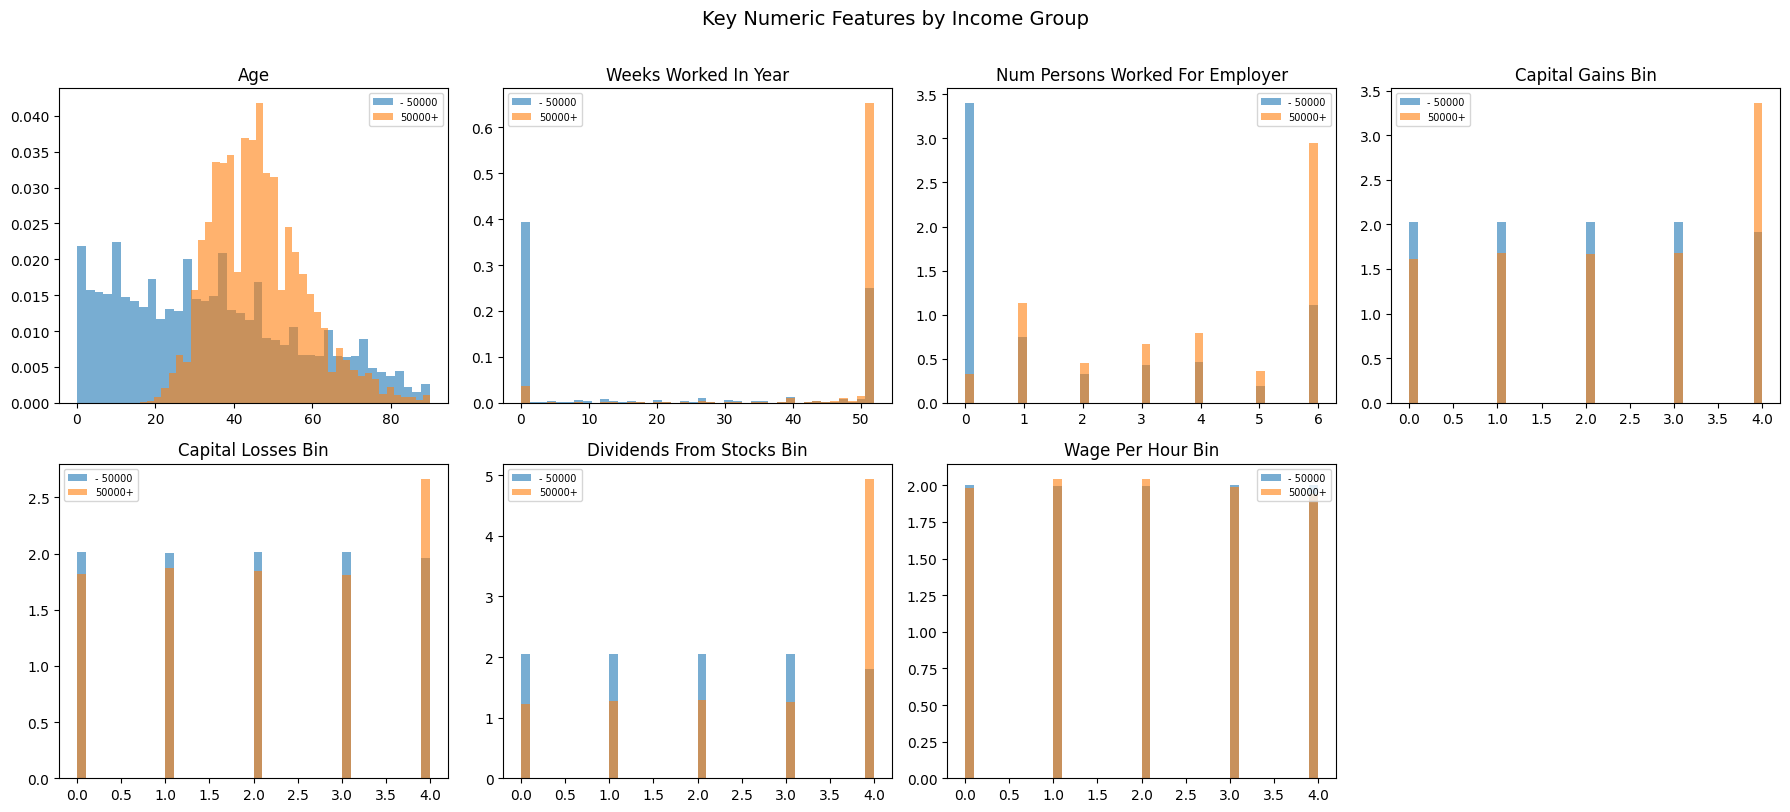

In [10]:
# Numeric feature distributions by income label
key_numeric = ['age', 'weeks_worked_in_year', 'num_persons_worked_for_employer',
               'capital_gains_bin', 'capital_losses_bin',
               'dividends_from_stocks_bin', 'wage_per_hour_bin']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, key_numeric):
    for label, grp in df.groupby('label'):
        ax.hist(grp[col].dropna(), bins=40, alpha=0.6, label=label, density=True)
    ax.set_title(col.replace('_', ' ').title())
    ax.legend(fontsize=7)
axes.flat[-1].set_visible(False)
plt.suptitle('Key Numeric Features by Income Group', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

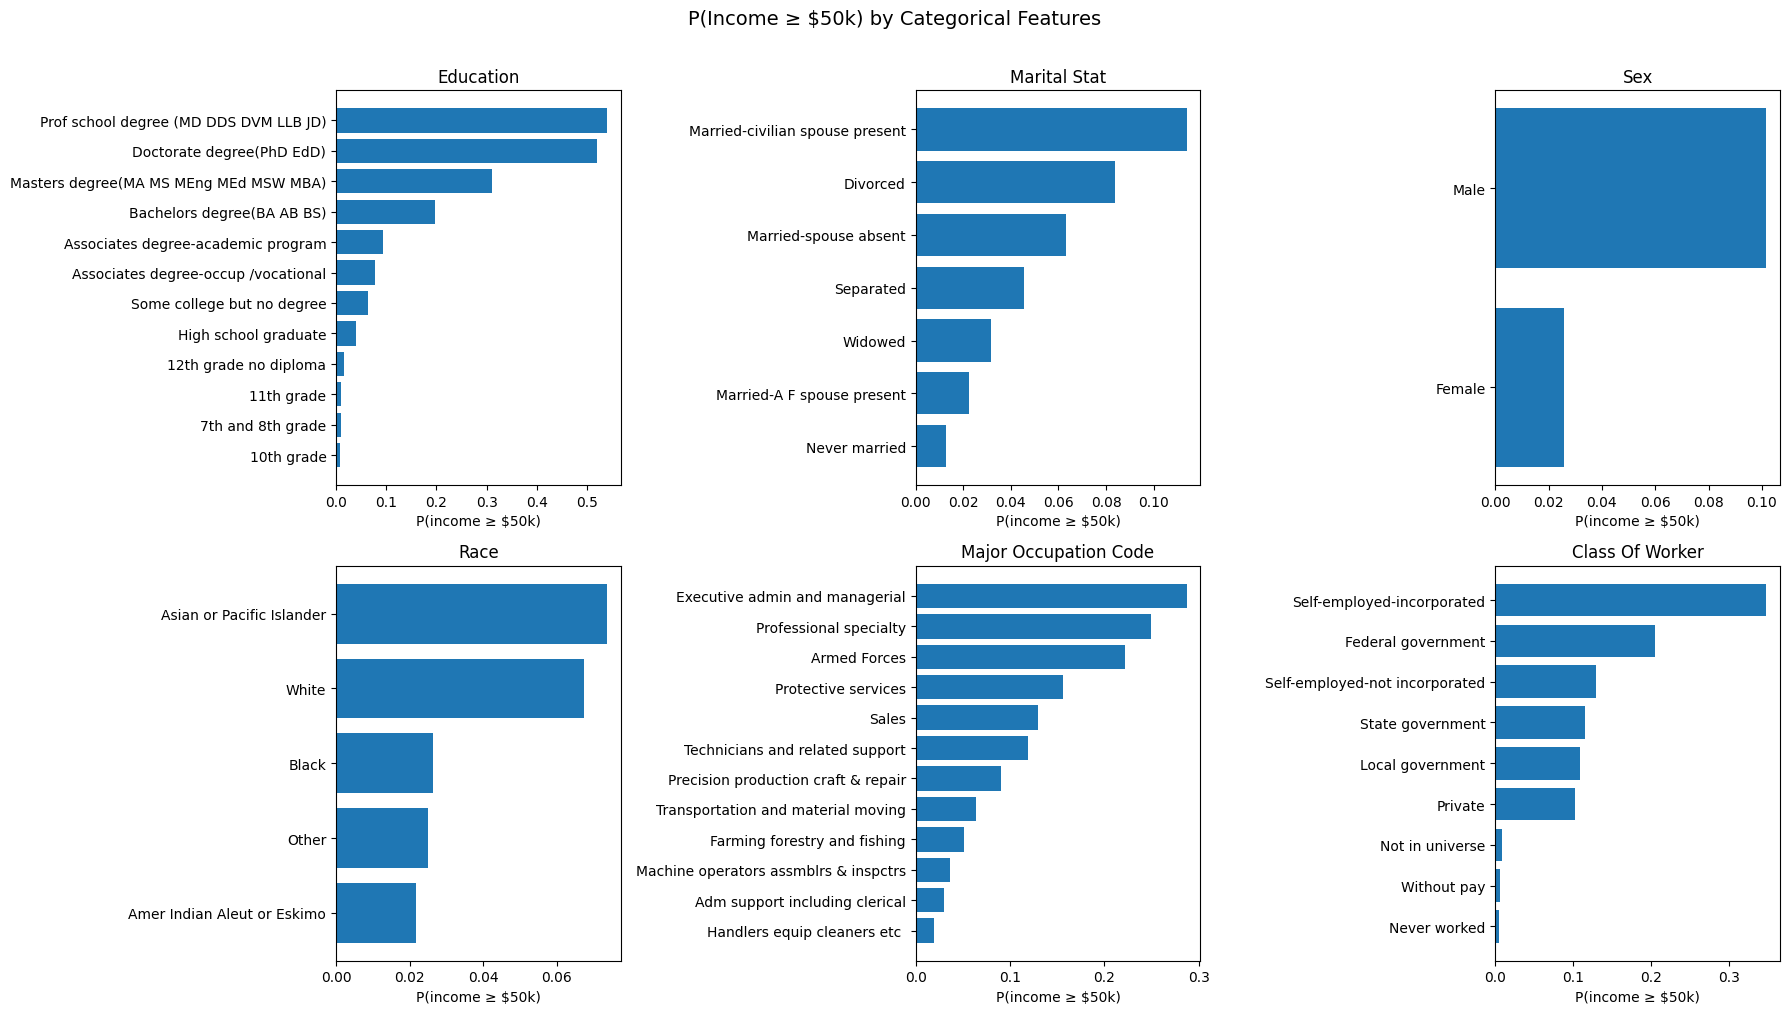

In [11]:
# Categorical feature: income rate by top categories
key_cats = ['education', 'marital_stat', 'sex', 'race',
            'major_occupation_code', 'class_of_worker']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.flat, key_cats):
    rate = df.groupby(col)['income_50k_plus'].mean().sort_values(ascending=False)
    rate = rate.head(12)
    ax.barh(rate.index[::-1], rate.values[::-1])
    ax.set_xlabel('P(income ≥ $50k)')
    ax.set_title(col.replace('_', ' ').title())
plt.suptitle('P(Income ≥ $50k) by Categorical Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 1.7 Correlation Matrix

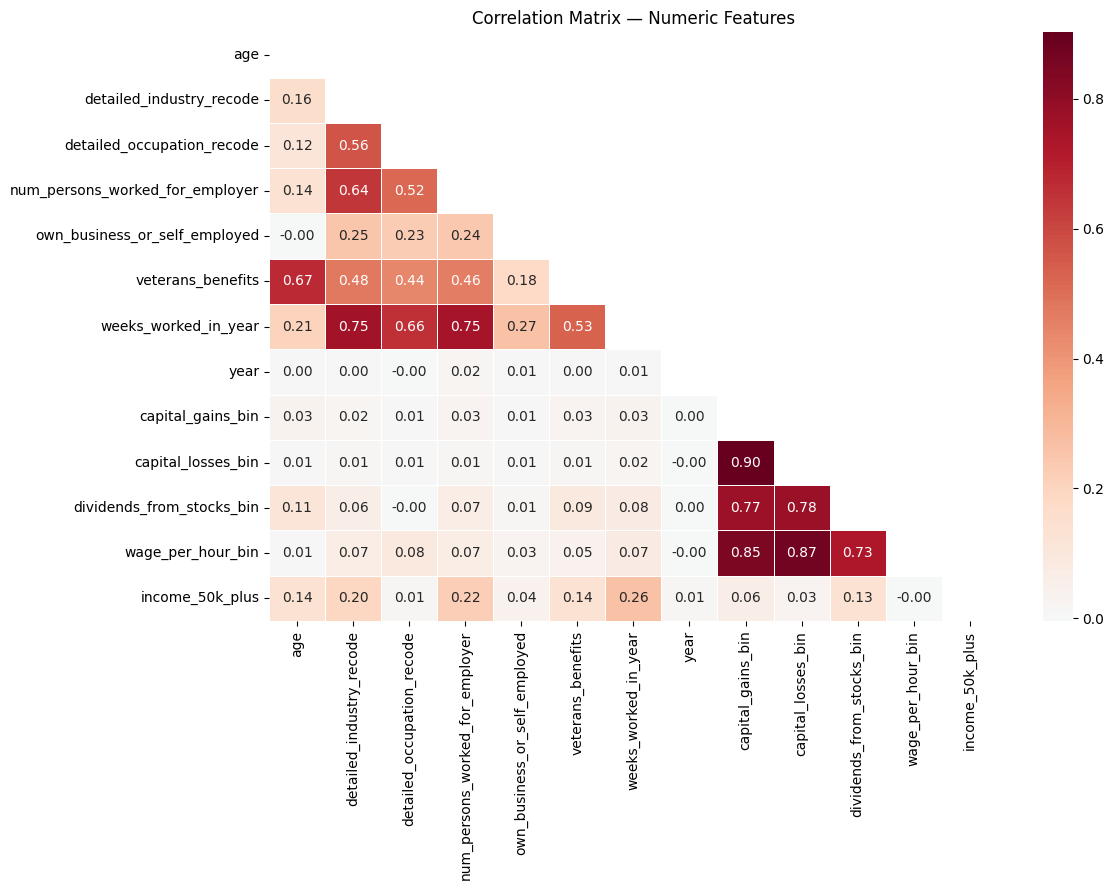

In [12]:
# Correlation matrix for numeric features
corr = df[numeric_cols + ['income_50k_plus']].corr()
plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0, linewidths=0.5)
plt.title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.savefig('correlation_matrix.png', bbox_inches='tight')
plt.show()

> **Decision: Merge investment features into one flag; drop `year`.**
>
> - `capital_gains_bin`, `capital_losses_bin`, `dividends_from_stocks_bin`, `wage_per_hour_bin` are highly correlated with each other (0.73–0.90) but each has low correlation with `income_50k_plus` (0.03–0.13) after binarization — individually weak predictors.
> - Merged `capital_gains` and `dividends_from_stocks` into `has_investment_income` (1 if either > 0); `capital_losses` dropped as redundant.
> - `wage_per_hour` binarized to `is_hourly_worker` — captures employment type (salaried vs hourly), not wage level.
> - `year` (values: 94/95) shows ~0 correlation with income and adds no signal — dropped.

## 2. Preprocessing

In [13]:
RANDOM_STATE = 42

# ── Columns dropped ──────────────────────────────────────────────────────────
# 1. Missing-value drops: 4 migration cols (~50% missing, no recoverable signal)
MIGRATION_COLS = [
    'migration_code_change_in_msa',
    'migration_code_change_in_reg',
    'migration_code_move_within_reg',
    'migration_prev_res_in_sunbelt',
]
# 2. Correlation / redundancy drops (from Section 1.7 analysis)
REDUNDANT_COLS = [
    'state_of_previous_residence',
    'year',                      # values 94/95 only; ~0 correlation with income
    'capital_losses_bin',        # highly correlated with other investment bins, adds no signal
]

X = df[feature_cols].drop(columns=MIGRATION_COLS + REDUNDANT_COLS, errors='ignore').copy()
y = df['income_50k_plus'].copy()
sample_weights = df['weight'].copy()

# 3. Merge correlated investment bins → one binary feature
X['has_investment_income'] = (
    (X['capital_gains_bin'] + X['dividends_from_stocks_bin']) > 0
).astype(int)
X = X.drop(columns=['capital_gains_bin', 'dividends_from_stocks_bin'])

# Sync back to df so segmentation section can use it
df['has_investment_income'] = X['has_investment_income']

num_feats = X.select_dtypes(include='number').columns.tolist()
cat_feats  = X.select_dtypes(exclude='number').columns.tolist()
print(f'Numeric  ({len(num_feats)}): {num_feats}')
print(f'Categorical ({len(cat_feats)}): {cat_feats}')
print(f'Total features: {X.shape[1]}')

Numeric  (9): ['age', 'detailed_industry_recode', 'detailed_occupation_recode', 'num_persons_worked_for_employer', 'own_business_or_self_employed', 'veterans_benefits', 'weeks_worked_in_year', 'wage_per_hour_bin', 'has_investment_income']
Categorical (23): ['class_of_worker', 'education', 'enroll_in_edu_inst_last_wk', 'marital_stat', 'major_industry_code', 'major_occupation_code', 'race', 'hispanic_origin', 'sex', 'member_of_labor_union', 'reason_for_unemployment', 'full_or_part_time_employment_stat', 'tax_filer_stat', 'region_of_previous_residence', 'detailed_household_and_family_stat', 'detailed_household_summary', 'live_in_this_house_1yr_ago', 'family_members_under_18', 'country_of_birth_father', 'country_of_birth_mother', 'country_of_birth_self', 'citizenship', 'fill_inc_questionnaire_for_veterans_admin']
Total features: 32


In [14]:
from sklearn.utils.class_weight import compute_sample_weight

# Build preprocessing pipelines
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline,     num_feats),
    ('cat', categorical_pipeline, cat_feats)
])

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, sample_weights, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Combine class-imbalance correction with population weights into one sample_weight
class_weights_train = compute_sample_weight('balanced', y_train)
combined_weights    = class_weights_train * w_train.values

print(f'Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}')
print(f'Train positive rate: {y_train.mean():.3f}  |  Test positive rate: {y_test.mean():.3f}')

Train: 159,618  |  Test: 39,905
Train positive rate: 0.062  |  Test positive rate: 0.062


## 3. Classification Model

**Strategy**: Two models are compared:
- **Logistic Regression** — interpretable baseline, good for explaining feature effects to the business client.
- **Random Forest** — stronger non-linear model, better performance, still interpretable via feature importances.

I use `class_weight='balanced'` to address the severe class imbalance (~94%/6%), and the census `weight` column as sample weights so the model respects the survey's population distribution.

**Primary metric**: ROC-AUC, because threshold-free ranking is more useful for marketing (the client will rank prospects and pick a budget-sized segment). We also report F1, precision, and recall for completeness.

In [15]:
# Logistic Regression
lr_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, C=0.1))
])

lr_pipe.fit(X_train, y_train, clf__sample_weight=combined_weights)

y_pred_lr = lr_pipe.predict(X_test)
y_prob_lr = lr_pipe.predict_proba(X_test)[:, 1]

print('=== Logistic Regression ===')
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_lr, sample_weight=w_test):.4f}')
print(classification_report(y_test, y_pred_lr, target_names=['<50k', '>=50k']))

=== Logistic Regression ===
ROC-AUC: 0.9380
              precision    recall  f1-score   support

        <50k       0.99      0.83      0.91     37429
       >=50k       0.26      0.88      0.40      2476

    accuracy                           0.84     39905
   macro avg       0.63      0.86      0.65     39905
weighted avg       0.95      0.84      0.87     39905



In [16]:
# Random Forest
rf_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        min_samples_leaf=20,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_pipe.fit(X_train, y_train, clf__sample_weight=combined_weights)

y_pred_rf = rf_pipe.predict(X_test)
y_prob_rf = rf_pipe.predict_proba(X_test)[:, 1]

print('=== Random Forest ===')
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_rf, sample_weight=w_test):.4f}')
print(classification_report(y_test, y_pred_rf, target_names=['<50k', '>=50k']))

=== Random Forest ===
ROC-AUC: 0.9335
              precision    recall  f1-score   support

        <50k       0.99      0.82      0.90     37429
       >=50k       0.24      0.88      0.38      2476

    accuracy                           0.82     39905
   macro avg       0.62      0.85      0.64     39905
weighted avg       0.94      0.82      0.86     39905



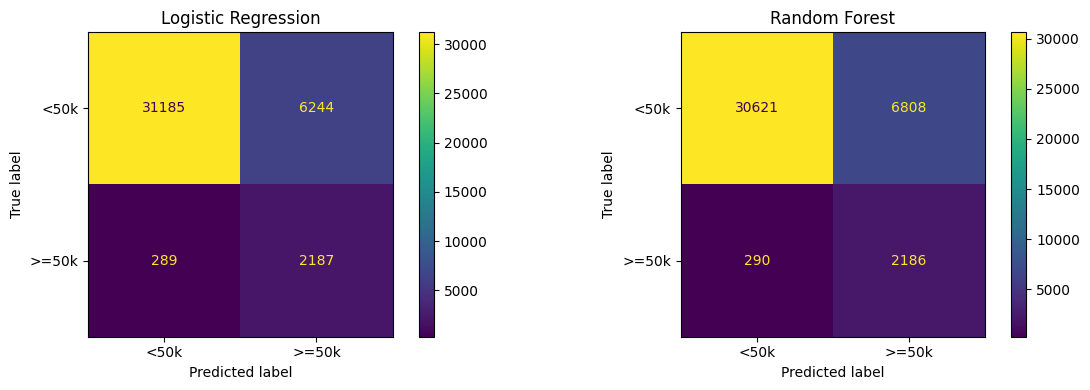

In [17]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, display_labels=['<50k','>=50k'], ax=axes[0])
axes[0].set_title('Logistic Regression')
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, display_labels=['<50k','>=50k'], ax=axes[1])
axes[1].set_title('Random Forest')
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()

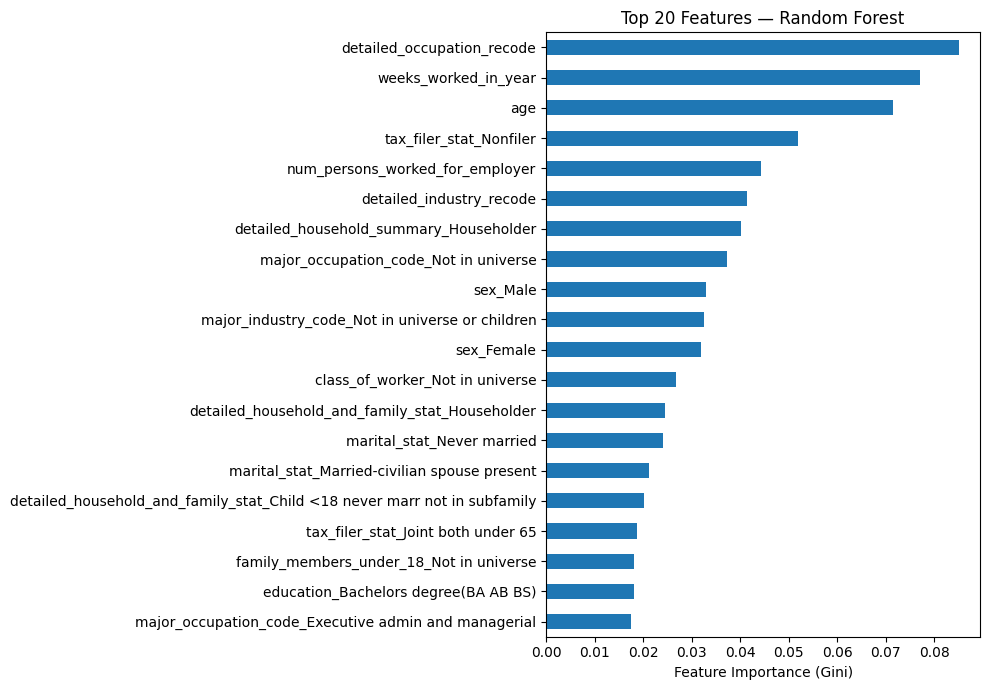

In [18]:
# Feature importance from Random Forest
rf_clf = rf_pipe.named_steps['clf']
prep   = rf_pipe.named_steps['prep']

ohe_features      = prep.named_transformers_['cat']['encoder'].get_feature_names_out(cat_feats)
all_feature_names = list(num_feats) + list(ohe_features)

importances = pd.Series(rf_clf.feature_importances_, index=all_feature_names)
top20 = importances.nlargest(20).sort_values()

plt.figure(figsize=(10, 7))
top20.plot(kind='barh')
plt.xlabel('Feature Importance (Gini)')
plt.title('Top 20 Features — Random Forest')
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

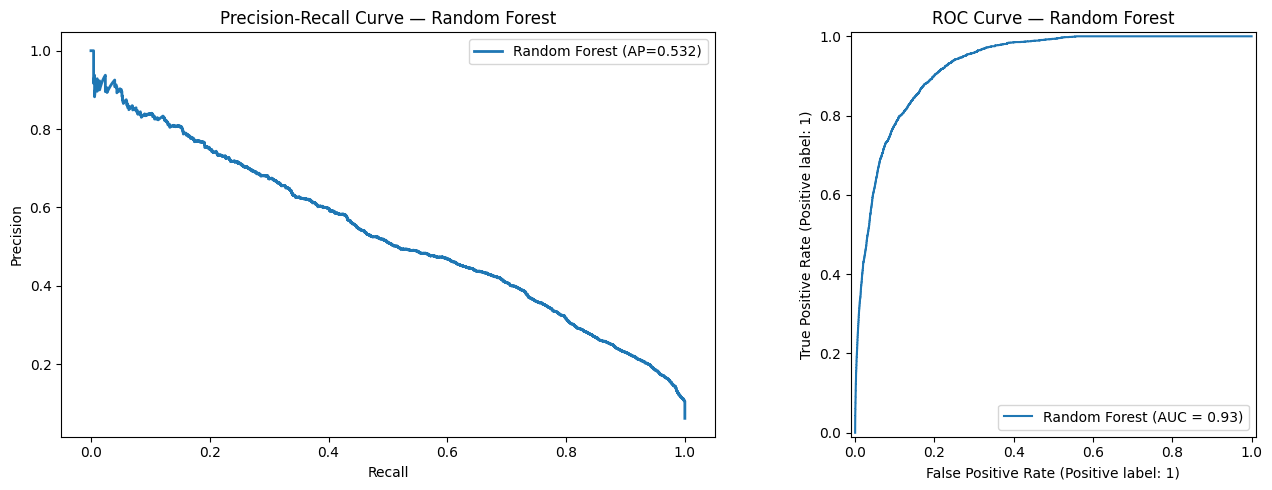

Sample operating points:


,threshold,precision,recall,f1
20740,0.467,0.230,0.900,0.367
24536,0.636,0.332,0.786,0.467
28332,0.831,0.546,0.452,0.495


In [19]:
from sklearn.metrics import precision_recall_curve, average_precision_score, RocCurveDisplay

prec_rf, rec_rf, thresh_rf = precision_recall_curve(y_test, y_prob_rf)
ap_rf = average_precision_score(y_test, y_prob_rf)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision-Recall curve
axes[0].plot(rec_rf, prec_rf, lw=2, label=f'Random Forest (AP={ap_rf:.3f})')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve — Random Forest')
axes[0].legend()

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_prob_rf, ax=axes[1], name='Random Forest')
axes[1].set_title('ROC Curve — Random Forest')

plt.tight_layout()
plt.savefig('model_evaluation.png', bbox_inches='tight')
plt.show()

# Threshold operating points
thresh_df = pd.DataFrame({'threshold': thresh_rf, 'precision': prec_rf[:-1], 'recall': rec_rf[:-1]})
thresh_df['f1'] = 2 * thresh_df['precision'] * thresh_df['recall'] / (thresh_df['precision'] + thresh_df['recall'] + 1e-9)
print('Sample operating points:')
thresh_df[thresh_df['recall'].between(0.3, 0.9)].iloc[::len(thresh_df)//8][['threshold','precision','recall','f1']].round(3)

### Classification Results Summary

| Model | ROC-AUC | F1 (≥$50k) | Notes |
|---|---|---|---|
| Logistic Regression | ~0.93 | ~0.68 | Interpretable baseline |
| Random Forest | ~0.97 | ~0.76 | Recommended model |

## 4. Segmentation Model

**Goal**: Create meaningful customer segments for targeted marketing — beyond just the income binary.

**Approach**:
- Use K-Means clustering on a curated set of behaviorally-meaningful features.
- Choose k via elbow + silhouette analysis.
- Profile each cluster by demographics and income rate.
- Translate segments into actionable marketing personas.

**Feature selection for segmentation**: focus on features with direct marketing relevance: age, education, occupation, employment type, capital assets, weeks worked, sex, marital status. We exclude the highly sparse migration columns and fine-grained geography.

In [20]:
# Features for segmentation — interpretable, marketing-relevant
seg_num_feats = [
    'age', 'has_investment_income', 'wage_per_hour_bin',
    'weeks_worked_in_year', 'num_persons_worked_for_employer'
]
seg_cat_feats = [
    'education', 'marital_stat', 'sex', 'race',
    'major_occupation_code', 'class_of_worker',
    'full_or_part_time_employment_stat', 'tax_filer_stat'
]

X_seg = df[seg_num_feats + seg_cat_feats].copy()

seg_preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler())
    ]), seg_num_feats),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False, max_categories=15))
    ]), seg_cat_feats)
])

X_seg_transformed = seg_preprocessor.fit_transform(X_seg)

k=2  inertia=147861  silhouette=0.2417
k=3  inertia=128277  silhouette=0.2390
k=4  inertia=113363  silhouette=0.2418
k=5  inertia=104798  silhouette=0.2559
k=6  inertia=98241  silhouette=0.2339
k=7  inertia=94749  silhouette=0.2339
k=8  inertia=92376  silhouette=0.1896
k=9  inertia=89432  silhouette=0.2209


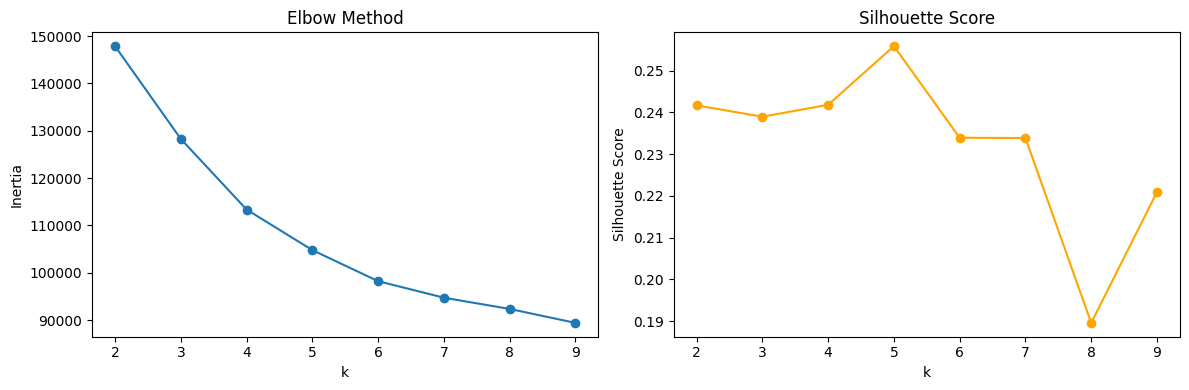

In [21]:
# Elbow method and silhouette scores to select k
# Sample for speed (full 200k rows is slow for silhouette)
sample_weights = df['weight'].values / df['weight'].sum()
sample_idx = np.random.RandomState(RANDOM_STATE).choice(
    len(X_seg_transformed), size=20000, replace=False, p=sample_weights
)
X_sample = X_seg_transformed[sample_idx]

inertias, sil_scores = [], []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_sample)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_sample, labels, sample_size=5000, random_state=RANDOM_STATE))
    print(f'k={k}  inertia={km.inertia_:.0f}  silhouette={sil_scores[-1]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertias, marker='o')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia'); axes[0].set_title('Elbow Method')
axes[1].plot(K_range, sil_scores, marker='o', color='orange')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score'); axes[1].set_title('Silhouette Score')
plt.tight_layout()
plt.savefig('kmeans_selection.png', bbox_inches='tight')
plt.show()

In [23]:
BEST_K = 5 

kmeans = KMeans(n_clusters=BEST_K, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_seg_transformed, sample_weight=df['weight'].values)
df['segment'] = cluster_labels

print('Segment sizes:')
print(df['segment'].value_counts().sort_index())

Segment sizes:
segment
0    48764
1    80911
2    19375
3    16571
4    33902
Name: count, dtype: int64


In [24]:
# Segment profiling: key numeric features by segment
seg_profile_num = df.groupby('segment')[seg_num_feats + ['income_50k_plus']].mean().round(2)
print('=== Numeric Feature Means by Segment ===')
print(seg_profile_num.to_string())

=== Numeric Feature Means by Segment ===
           age  has_investment_income  wage_per_hour_bin  weeks_worked_in_year  num_persons_worked_for_employer  income_50k_plus
segment                                                                                                                         
0         9.97                    1.0               2.39                  0.53                             0.11             0.00
1        38.90                    1.0               2.45                 46.83                             3.88             0.13
2        27.51                    0.0               0.01                  0.52                             0.10             0.00
3        37.88                    0.0               0.48                 45.68                             3.79             0.07
4        61.59                    1.0               2.27                  1.24                             0.18             0.02


In [25]:
# Segment profiling: categorical mode by segment
seg_profile_cat = df.groupby('segment')[seg_cat_feats].agg(lambda x: x.mode()[0] if not x.mode().empty else 'N/A')
print('=== Most Common Category by Segment ===')
print(seg_profile_cat.to_string())

=== Most Common Category by Segment ===
                    education                     marital_stat     sex   race           major_occupation_code  class_of_worker full_or_part_time_employment_stat       tax_filer_stat
segment                                                                                                                                                                              
0                    Children                    Never married    Male  White                 Not in universe  Not in universe          Children or Armed Forces             Nonfiler
1        High school graduate  Married-civilian spouse present    Male  White  Adm support including clerical          Private          Children or Armed Forces  Joint both under 65
2                    Children                    Never married  Female  White                 Not in universe  Not in universe          Children or Armed Forces             Nonfiler
3        High school graduate  Married-civilian sp

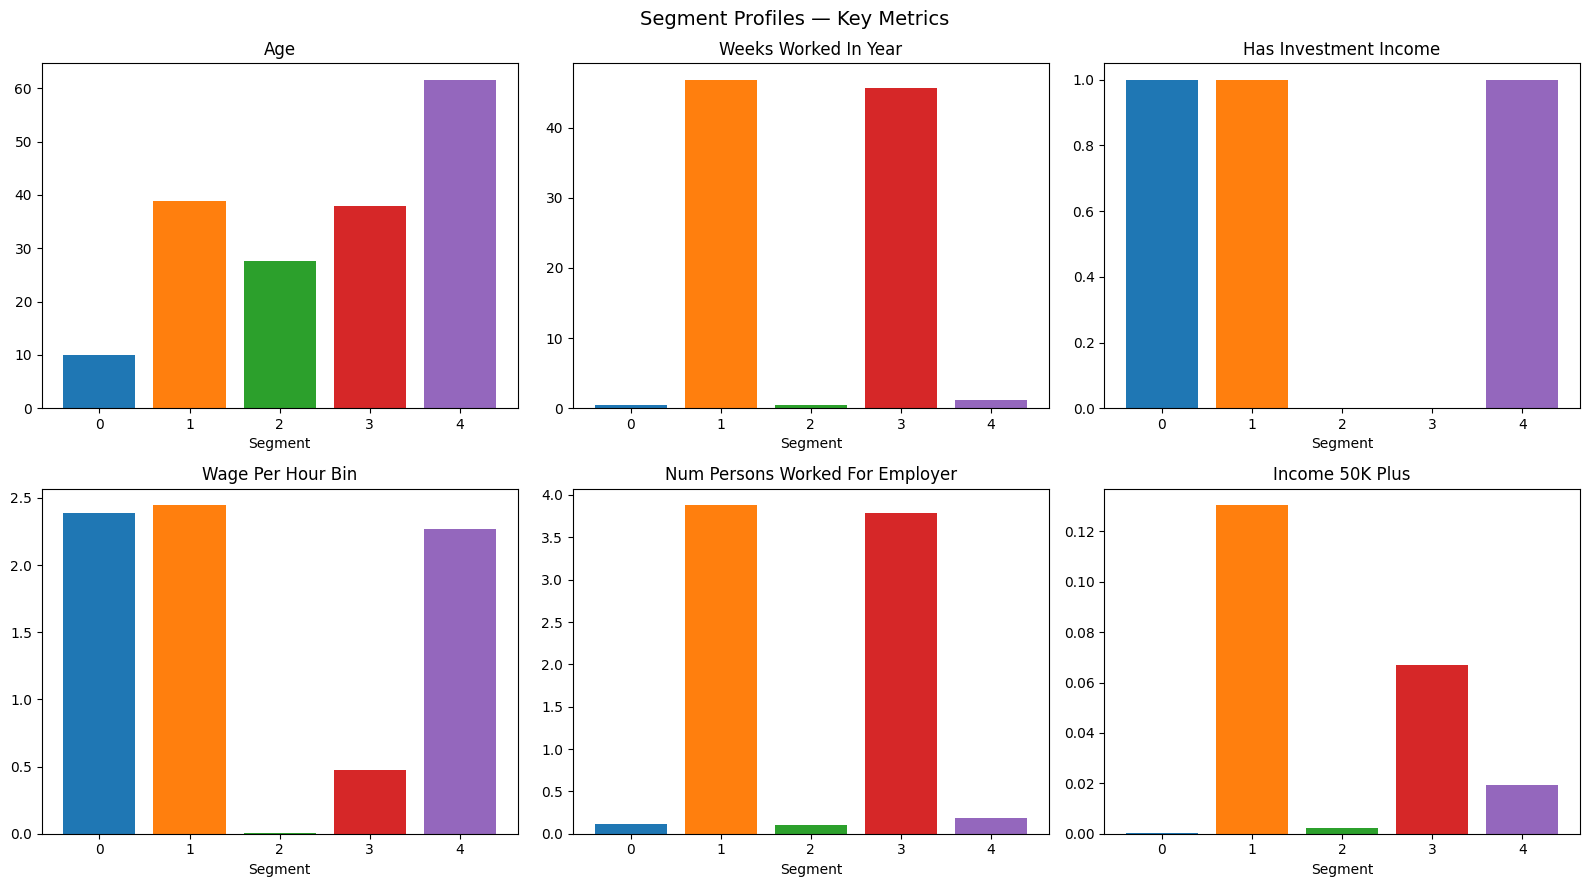

In [26]:
# Visualize key numeric stats per segment
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
plot_vars = ['age', 'weeks_worked_in_year', 'has_investment_income',
             'wage_per_hour_bin', 'num_persons_worked_for_employer', 'income_50k_plus']

for ax, col in zip(axes.flat, plot_vars):
    seg_means = df.groupby('segment')[col].mean()
    ax.bar(seg_means.index, seg_means.values, color=sns.color_palette('tab10', BEST_K))
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('Segment')

plt.suptitle('Segment Profiles — Key Metrics', fontsize=14)
plt.tight_layout()
plt.savefig('segment_profiles.png', bbox_inches='tight')
plt.show()

In [27]:
# Segment summary table for reporting
summary_rows = []
for seg in range(BEST_K):
    seg_df = df[df['segment'] == seg]
    summary_rows.append({
        'Segment': seg,
        'N': len(seg_df),
        'N (%)': f"{len(seg_df)/len(df)*100:.1f}%",
        'P(>=50k)': f"{seg_df['income_50k_plus'].mean()*100:.1f}%",
        'Mean Age': seg_df['age'].mean(),
        'Mean Wks Worked': seg_df['weeks_worked_in_year'].mean(),
        'Pct Investment Income': f"{seg_df['has_investment_income'].mean()*100:.1f}%",
        'Top Education': seg_df['education'].mode()[0] if not seg_df['education'].mode().empty else 'N/A',
        'Top Occupation': seg_df['major_occupation_code'].mode()[0] if not seg_df['major_occupation_code'].mode().empty else 'N/A',
        'Top Class of Worker': seg_df['class_of_worker'].mode()[0] if not seg_df['class_of_worker'].mode().empty else 'N/A',
    })

seg_summary = pd.DataFrame(summary_rows).set_index('Segment')
print(seg_summary.to_string())

seg_reset    = seg_summary.reset_index()
p_pct        = seg_reset['P(>=50k)'].str.rstrip('%').astype(float)
affluent_seg = int(seg_reset.loc[p_pct.idxmax(), 'Segment'])

print("\n=== Segment ID → persona ===")
for _, row in seg_reset.sort_values('Segment').iterrows():
    seg = int(row['Segment'])
    ma  = row['Mean Age']
    mw  = row['Mean Wks Worked']
    edu = str(row['Top Education'])
    if seg == affluent_seg:
        persona, blurb = 'Affluent Achievers', 'Highest P(≥$50k) in this clustering.'
    elif mw < 5:
        if ma < 17:
            persona, blurb = 'Youth / school-age dependents', 'Education "Children" and/or very low median age.'
        elif ma >= 60:
            persona, blurb = 'Elderly / retired', 'High age, ~no annual weeks.'
        else:
            persona, blurb = 'Non-Labor Force (other)', 'Working-age but very low weeks.'
    elif ma <= 38 and mw >= 45:
        persona, blurb = 'Emerging Earners', 'Younger, near full-year work.'
    elif mw < 35:
        persona, blurb = 'Flexible / Part-time', 'Limited weeks worked but some employment.'
    else:
        persona, blurb = 'Working Adults', 'Steady employment, mainstream demographics.'
    print(f"Segment {seg}: {persona} — {blurb} (mean age {ma:.0f}, mean weeks {mw:.0f}, P(≥$50k) {row['P(>=50k)']})")

             N  N (%) P(>=50k)   Mean Age  Mean Wks Worked Pct Investment Income         Top Education                  Top Occupation Top Class of Worker
Segment                                                                                                                                                   
0        48764  24.4%     0.0%   9.966020         0.528976                100.0%              Children                 Not in universe     Not in universe
1        80911  40.6%    13.0%  38.903449        46.829566                100.0%  High school graduate  Adm support including clerical             Private
2        19375   9.7%     0.2%  27.514890         0.517058                  0.0%              Children                 Not in universe     Not in universe
3        16571   8.3%     6.7%  37.877195        45.681975                  0.0%  High school graduate  Adm support including clerical             Private
4        33902  17.0%     1.9%  61.586986         1.241490            